<a href="https://colab.research.google.com/github/PavelS130/aprendizaje-maquina-estadistico-pavel/blob/master/Copia_de_PAVEL_BC_Taller_PDE_Onda_Condiciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 Taller: Ecuación de onda 1D y condiciones de frontera (DeepXDE)

**Objetivo:** comparar una **PINN (DeepXDE)** con una **referencia numérica (FDM)** para la ecuación de onda 1D bajo distintas condiciones de frontera.

## Ecuación de onda 1D

$$
\frac{\partial^2 u}{\partial t^2} = c^2\,\frac{\partial^2 u}{\partial x^2},\quad x\in[0,1],\ t>0,\quad c=1.
$$

Exploraremos 8 variantes (1: Dirichlet, 2: Neumann, 3: Robin, 4: Operador, 5: Periódica, 6: Inicial, 7: Interior, 8: Multi-frontera).

In [ ]:
# ✅ Instalación y librerías
!pip -q install deepxde matplotlib numpy scipy
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from math import isclose
np.set_printoptions(precision=4, suppress=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.7 MB/s eta 0:00:00
No backend selected.
Finding available backend...


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
Instructions for updating:
non-resource variables are not supported in the long term


Found tensorflow.compat.v1
Setting the default backend to "tensorflow.compat.v1". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


## Definición base: dominio espacio-tiempo y PDE de onda

In [ ]:
c = 1.0  # velocidad de onda

def pde(X, y):
    # X = [x, t], y = u(x,t)
    u_tt = dde.grad.hessian(y, X, i=1, j=1)
    u_xx = dde.grad.hessian(y, X, i=0, j=0)
    return u_tt - (c**2) * u_xx

geom = dde.geometry.Interval(0.0, 1.0)
timedomain = dde.geometry.TimeDomain(0.0, 1.0)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

## Solución de referencia (FDM explícito) para Dirichlet
Imponemos Dirichlet homogéneo en los bordes y un pulso inicial. (Para otros casos, puedes adaptar las condiciones al avanzar en el tiempo.)

In [ ]:
def solve_wave_fd_dirichlet(nx=101, nt=201, c=1.0, L=1.0, T=1.0):
    dx = L / (nx - 1)
    dt = T / (nt - 1)
    r = c * dt / dx
    if r > 1.0:
        print(f"Advertencia CFL: c*dt/dx = {r:.3f} > 1.0 (inestable)")

    x = np.linspace(0.0, L, nx)
    t = np.linspace(0.0, T, nt)
    u = np.zeros((nt, nx))

    # CI: desplazamiento inicial (sin velocidad inicial)
    u[0, :] = np.sin(np.pi * x)  # compatible con Dirichlet homogéneo
    # primer paso (leap-frog con ut=0)
    u[1, 1:-1] = u[0, 1:-1] + 0.5 * (r**2) * (u[0, 2:] - 2*u[0, 1:-1] + u[0, :-2])
    # aplicar Dirichlet en bordes
    u[1, 0] = 0.0
    u[1, -1] = 0.0

    for n in range(1, nt - 1):
        u[n+1, 1:-1] = (2*u[n, 1:-1] - u[n-1, 1:-1]
                         + (r**2) * (u[n, 2:] - 2*u[n, 1:-1] + u[n, :-2]))
        # Dirichlet en cada paso
        u[n+1, 0] = 0.0
        u[n+1, -1] = 0.0
    return x, t, u

## 🔸 Caso 1: Dirichlet homogéneo

$$u(0,t)=0,\quad u(1,t)=0,\quad u(x,0)=\sin(\pi x),\quad u_t(x,0)=0.$$

In [ ]:
# BC en x=0 y x=1 (funciones booleanas punto a punto)
bc_left  = dde.icbc.DirichletBC(
    geomtime,
    lambda X: 0.0,
    lambda X, on_boundary: on_boundary and isclose(float(X[0]), 0.0)
)
bc_right = dde.icbc.DirichletBC(
    geomtime,
    lambda X: 0.0,
    lambda X, on_boundary: on_boundary and isclose(float(X[0]), 1.0)
)

# Condiciones iniciales: u(x,0) y u_t(x,0)=0
ic_u  = dde.icbc.IC(
    geomtime,
    lambda X: np.sin(np.pi * X[:, 0:1]),
    lambda _, on_initial: on_initial
)
ic_ut = dde.icbc.OperatorBC(
    geomtime,
    lambda X, y, _: dde.grad.jacobian(y, X, i=0, j=1),  # u_t = 0
    lambda X, on_initial: on_initial
)

data = dde.data.TimePDE(
    geomtime, pde, [bc_left, bc_right, ic_u, ic_ut],
    num_domain=2000, num_boundary=100, num_initial=200
)
net = dde.nn.FNN([2, 50, 50, 50, 1], activation="tanh", kernel_initializer="Glorot uniform")
model = dde.Model(data, net)
model.compile(optimizer="adam", lr=0.001)
losshistory, train_state = model.train(epochs=4000, display_every=1000)

Compiling model...
Building feed-forward neural network...
'build' took 0.073359 s

'compile' took 0.683366 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [1.08e-03, 2.39e-02, 2.84e-02, 5.18e-01, 7.05e-02]    [1.08e-03, 2.39e-02, 2.84e-02, 5.18e-01, 7.05e-02]    []  
1000      [2.68e-04, 2.22e-05, 3.06e-04, 3.37e-04, 3.93e-04]    [2.68e-04, 2.22e-05, 3.06e-04, 3.37e-04, 3.93e-04]    []  
2000      [4.42e-05, 1.16e-06, 1.07e-06, 3.25e-05, 7.57e-05]    [4.42e-05, 1.16e-06, 1.07e-06, 3.25e-05, 7.57e-05]    []  
3000      [2.24e-05, 5.14e-07, 1.62e-06, 1.70e-05, 6.96e-05]    [2.24e-05, 5.14e-07, 1.62e-06, 1.70e-05, 6.96e-05]    []  
4000      [1.93e-05, 6.47e-07, 9.52e-07, 1.59e-05, 6.65e-05]    [1.93e-05, 6.47e-07, 9.52e-07, 1.59e-05, 6.65e-05]    []  

Best model at step 4000:
  train loss: 1.03e-04
  test loss: 1.03e-04
  test metric: []

'train' took 146.170778 s



### Comparación PINN vs FDM (Dirichlet)

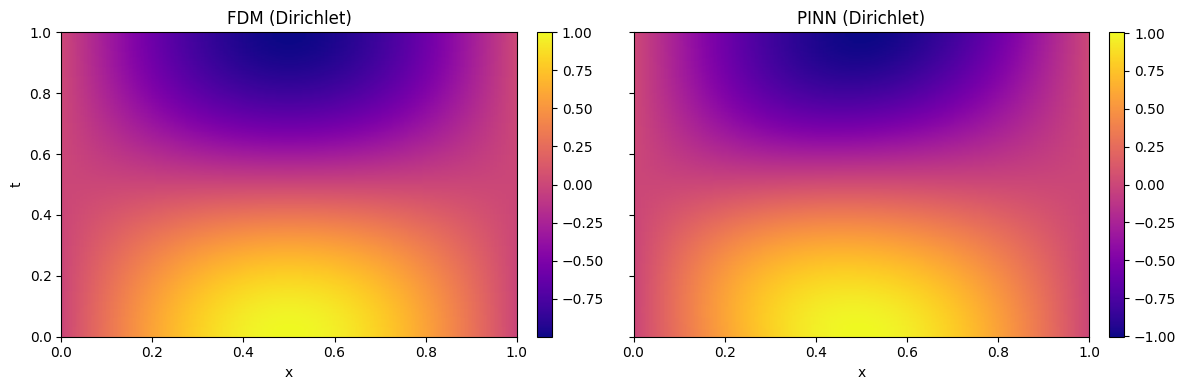

Error relativo L2 (PINN vs FDM): 6.029e-02


In [ ]:
x, t, u_fd = solve_wave_fd_dirichlet(nx=121, nt=241, c=1.0, L=1.0, T=1.0)
Xg, Tg = np.meshgrid(x, t)
XT = np.hstack((Xg.reshape(-1, 1), Tg.reshape(-1, 1)))
u_pinn = model.predict(XT).reshape(Tg.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
im0 = axs[0].imshow(u_fd, extent=[0, 1, 0, 1], origin='lower', aspect='auto', cmap='plasma')
axs[0].set_title('FDM (Dirichlet)'); axs[0].set_xlabel('x'); axs[0].set_ylabel('t')
im1 = axs[1].imshow(u_pinn, extent=[0, 1, 0, 1], origin='lower', aspect='auto', cmap='plasma')
axs[1].set_title('PINN (Dirichlet)'); axs[1].set_xlabel('x')
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# Error L2 relativo en toda la rejilla (como referencia rápida)
num = np.linalg.norm(u_pinn - u_fd)
den = np.linalg.norm(u_fd) + 1e-12
print(f"Error relativo L2 (PINN vs FDM): {num/den:.3e}")

## 🔹 Plantillas para Casos 2–8
Duplíca las celdas del **Caso 1** y cambia **sólo las condiciones**:

2) **Neumann:** $u_x(0,t)=0,\ u_x(1,t)=0$  
3) **Robin:** $u_x(0,t)+h u(0,t)=0,\ u_x(1,t)+h u(1,t)=0$  
4) **Operador:** $u_t(0,t)+u(0,t)=0$  
5) **Periódica:** $u(0,t)=u(1,t),\ u_x(0,t)=u_x(1,t)$  
6) **Inicial (variantes de $u(x,0)$ o $u_t(x,0)$)**  
7) **Interior:** $u(0.5,t)=0$  
8) **Multi-frontera:** $u(0,t)=0,\ u_x(1,t)=0$  

> **Nota didáctica:** al comparar con FDM, recuerda adaptar el esquema de referencia para reflejar **la misma condición** (por ejemplo, en Neumann, imponiendo derivadas nulas en los extremos en cada paso).

In [ ]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from math import isclose

In [ ]:

# Suponemos que ya tienes definida `pde` y `solve_wave_fd_dirichlet`

# Dominio espacio-temporal
L, T = 1.0, 1.0
geom = dde.geometry.Interval(0, L)
timedomain = dde.geometry.TimeDomain(0, T)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [ ]:
# -------------------------------------------------
# 4. Condición interior: u(0.5, t) = 0  → usando PointSetBC
# -------------------------------------------------
num_bc_points = 100
t_vals = np.linspace(0, T, num_bc_points)
X_bc = np.column_stack((0.5 * np.ones(num_bc_points), t_vals))
y_bc = np.zeros(num_bc_points)

bc_mid = dde.icbc.PointSetBC(X_bc, y_bc)

# -------------------------------------------------
# 5. Condiciones iniciales (sin cambios)
# -------------------------------------------------
ic_u = dde.icbc.IC(
    geomtime,
    lambda X: np.sin(np.pi * X[:, 0:1]),
    lambda _, on_initial: on_initial
)

ic_ut = dde.icbc.OperatorBC(
    geomtime,
    lambda X, y, _: dde.grad.jacobian(y, X, i=0, j=1),  # u_t = 0
    lambda _, on_initial: on_initial
)

# -------------------------------------------------
# 6. Datos del problema
# -------------------------------------------------
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc_mid, ic_u, ic_ut],
    num_domain=2000,
    num_boundary=0,      # PointSetBC no usa num_boundary
    num_initial=200
)

In [ ]:
# -------------------------------------------------
# Red neuronal y entrenamiento
# -------------------------------------------------
net = dde.nn.FNN([2, 50, 50, 50, 1], activation="tanh", kernel_initializer="Glorot uniform")
model = dde.Model(data, net)
model.compile(optimizer="adam", lr=0.001)

# Nota: en DeepXDE ≥1.0, usa 'iterations' en lugar de 'epochs'
losshistory, train_state = model.train(iterations=4000, display_every=1000)

Compiling model...
Building feed-forward neural network...
'build' took 0.073263 s

'compile' took 0.701909 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [1.08e-03, 2.88e-02, 5.18e-01, nan]         [1.08e-03, 2.88e-02, 5.18e-01, nan]         []  

Best model at step 0:
  train loss: inf
  test loss: inf
  test metric: 

'train' took 0.652763 s



In [ ]:
# -------------------------------------------------
# Comparación con FDM (ajustar FDM para condición interior)
# -------------------------------------------------
# ⚠️ IMPORTANTE: tu función solve_wave_fd_dirichlet actual asume Dirichlet en x=0 y x=1.
# Para comparar con u(0.5,t)=0, necesitas MODIFICAR el método de diferencias finitas.
# Pero como eso es complejo, aquí solo evaluamos la PINN.

# Generar malla para visualización
x_plot = np.linspace(0, 1, 101)
t_plot = np.linspace(0, 1, 101)
Xg, Tg = np.meshgrid(x_plot, t_plot)
XT = np.hstack((Xg.reshape(-1, 1), Tg.reshape(-1, 1)))
u_pinn = model.predict(XT).reshape(Tg.shape)

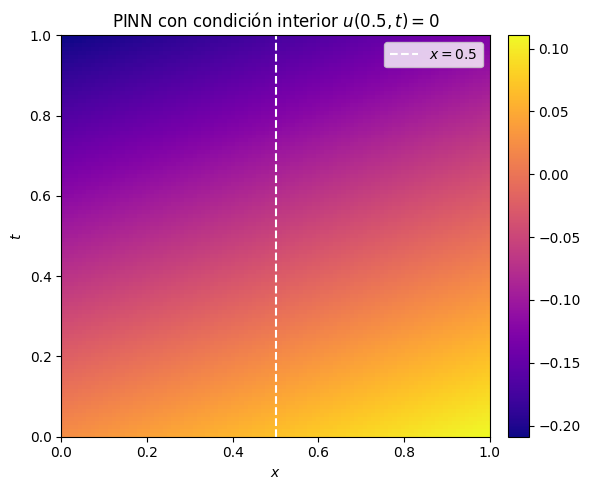

In [ ]:
# Visualización
plt.figure(figsize=(6, 5))
im = plt.imshow(
    u_pinn,
    extent=[0, 1, 0, 1],
    origin='lower',
    aspect='auto',
    cmap='plasma'
)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title('PINN con condición interior $u(0.5,t)=0$')
plt.xlabel('$x$')
plt.ylabel('$t$')

# Línea vertical en x=0.5 para destacar la condición
plt.axvline(x=0.5, color='white', linestyle='--', linewidth=1.5, label='$x=0.5$')
plt.legend()
plt.tight_layout()
plt.show()